<a href="https://colab.research.google.com/github/prabhaM07/Machine-learning/blob/main/diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn import svm
from sklearn import metrics
from sklearn.metrics import accuracy_score, mean_squared_error, precision_recall_curve
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold
from scipy.stats import ttest_rel
from scipy.stats import randint
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.datasets import make_classification
from sklearn.preprocessing import binarize, LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import zscore
from scipy.stats import probplot
from xgboost import XGBClassifier

READ DATASET

In [ ]:
df = pd.read_csv('/content/diabetes_prediction_dataset.csv')

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None


In [ ]:
df.replace('No Info', float('nan'), inplace=True)


In [ ]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['blood_glucose_level'] = pd.to_numeric(df['blood_glucose_level'], errors='coerce')

In [ ]:
numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

In [ ]:
# removing an outliers

z_scores = zscore(df[numerical_cols])

# Set a threshold for outlier detection (e.g., 3 standard deviations)
threshold = 4

# Identify and remove outliers
outliers_mask = (abs(z_scores) > threshold).any(axis=1)

df = df[~outliers_mask]
row=df.shape[0]
print(row)
df=df.dropna()
row=df.shape[0]
row

99617


63889

In [ ]:
numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
print(df[numerical_cols])
df[numerical_cols] = StandardScaler().fit_transform(df[numerical_cols])
print(df[numerical_cols])

        age    bmi  HbA1c_level  blood_glucose_level
0      80.0  25.19          6.6                  140
1      54.0  27.32          6.6                   80
2      28.0  27.32          5.7                  158
3      36.0  23.45          5.0                  155
4      76.0  20.14          4.8                  155
...     ...    ...          ...                  ...
99995  80.0  27.32          6.2                   90
99996   2.0  17.37          6.5                  100
99997  66.0  27.83          5.7                  155
99998  24.0  35.42          4.0                  100
99999  57.0  22.43          6.6                   90

[100000 rows x 4 columns]
            age       bmi  HbA1c_level  blood_glucose_level
0      1.692704 -0.321056     1.001706             0.047704
1      0.538006 -0.000116     1.001706            -1.426210
2     -0.616691 -0.000116     0.161108             0.489878
3     -0.261399 -0.583232    -0.492690             0.416183
4      1.515058 -1.081970    -0.67949

<ipython-input-16-bcfbb7afc424>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot = True, cmap = 'RdPu')


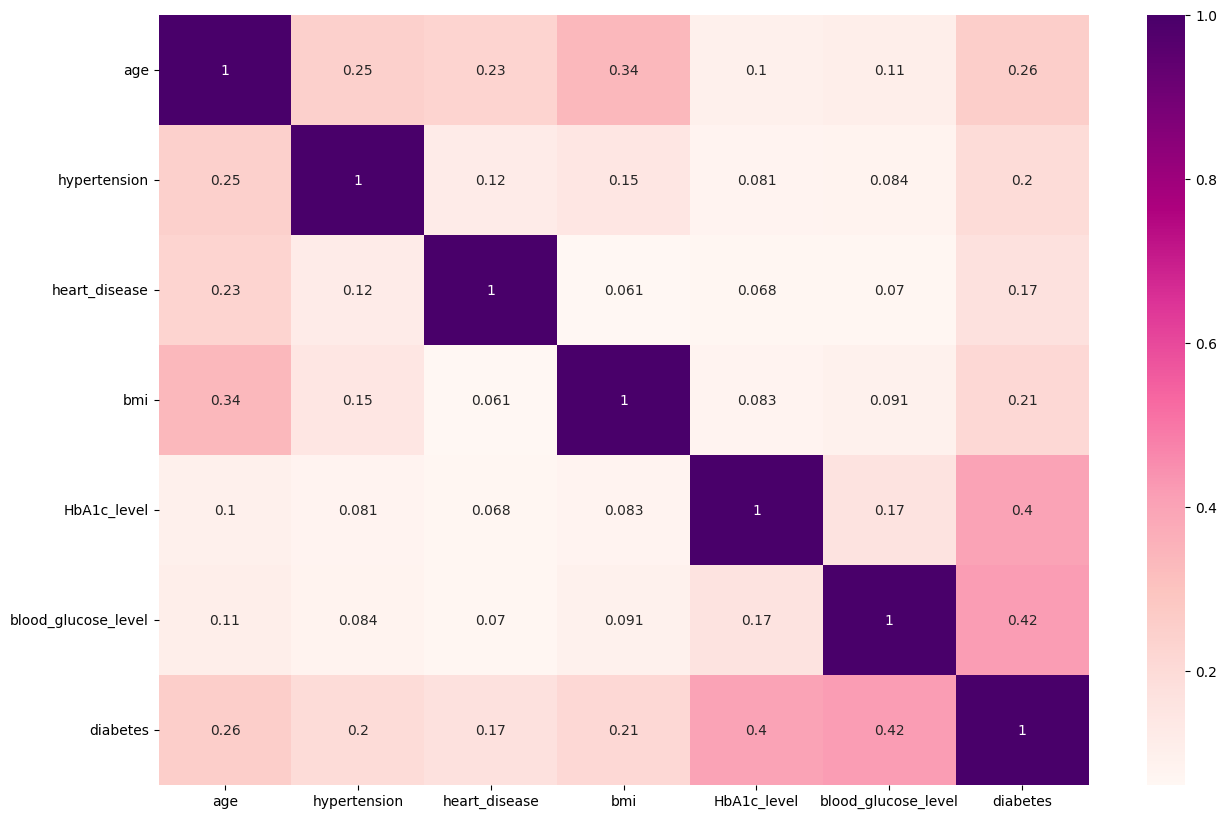

In [ ]:
import seaborn as sns
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot = True, cmap = 'RdPu')
plt.show()

In [ ]:
print(df.columns)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')


In [ ]:
print(df['smoking_history'].unique())

['never' 'current' 'former' 'ever' 'not current']


In [ ]:
categorical_cols = ['gender', 'smoking_history']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [ ]:
print(df.describe())

In [ ]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

age                            0.124346
hypertension                   0.023292
heart_disease                  0.015618
bmi                            0.137016
HbA1c_level                    0.345349
blood_glucose_level            0.333298
gender_Male                    0.006762
gender_Other                   0.000005
smoking_history_ever           0.002698
smoking_history_former         0.004336
smoking_history_never          0.004369
smoking_history_not current    0.002912
dtype: float64


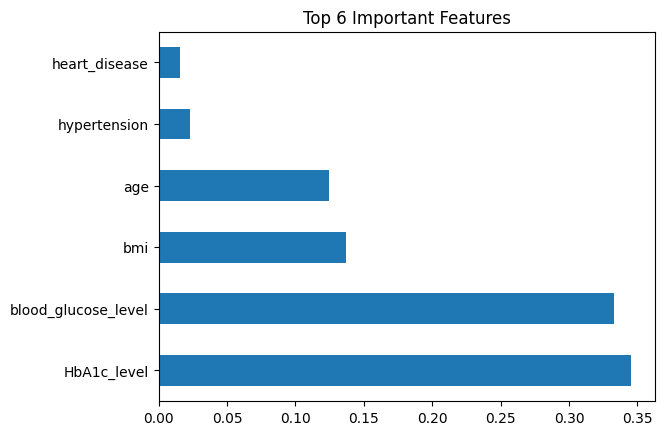

In [ ]:
# Feature Selection using Extra Trees Classifier
model = ExtraTreesClassifier()
model.fit(X, y)

# Display feature importances
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
print(feature_importances)
feature_importances.nlargest(6).plot(kind='barh')
plt.title('Top 6 Important Features')
plt.show()

In [ ]:
# Fit SelectKBest on the original features and transform both X and X_resampled
selector = SelectKBest(f_classif, k=6).fit(X, y)
X_selected = selector.transform(X)
X_resampled_selected = selector.transform(X)

In [ ]:
target_distribution = y.value_counts(normalize=True) * 100

# Print the percentage distribution
target_distribution

0    89.131149
1    10.868851
Name: diabetes, dtype: float64

In [ ]:
# Assuming 'diabetes' is the target column
target_frequency = df['diabetes'].value_counts()

print(target_frequency)


0    56945
1     6944
Name: diabetes, dtype: int64


In [ ]:
# by applying SMOTE

from imblearn.over_sampling import SMOTE

# Example: Oversample the minority class using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_resampled_selected, y)

In [ ]:
target_distribution = y_resampled.value_counts(normalize=True) * 100

# Print the percentage distribution
target_distribution

0    50.0
1    50.0
Name: diabetes, dtype: float64

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


1

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# Create an XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', seed=42)

# Define the parameter distributions for randomized search
param_dist = {
    'learning_rate': np.linspace(0.01, 0.1, 10),         # Step size shrinkage
    'n_estimators': [50, 100, 150, 200],                   # Number of boosting rounds
    'max_depth': [3, 4, 5, 6],                            # Maximum depth of a tree
    'subsample': np.linspace(0.8, 1.0, 3),                # Subsample ratio of the training instances
    'colsample_bytree': np.linspace(0.8, 1.0, 3),         # Subsample ratio of columns when constructing each tree
    'gamma': np.linspace(0, 0.2, 5),                      # Minimum loss reduction required to make a further partition on a leaf node
    'reg_alpha': np.linspace(0, 0.5, 5),                  # L1 regularization term on weights
    'reg_lambda': np.linspace(0, 0.5, 5),                 # L2 regularization term on weights
    'scale_pos_weight': [1, 2, 3]                         # Controls the balance of positive and negative weights
}

# Create RandomizedSearchCV object
randomized_model = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, n_iter=10, cv=5, scoring='accuracy', random_state=42)

# Fit the randomized search to the data
randomized_model.fit(X_train, y_train)

# Identify the best parameters
best_params_random = randomized_model.best_params_
df_random = pd.DataFrame(randomized_model.cv_results_)
print(df_random)

# Evaluate the XGBoost model
xgb_train_score = round(accuracy_score(y_train, randomized_model.best_estimator_.predict(X_train)) * 100, 2)
xgb_test_score = round(accuracy_score(y_test, randomized_model.best_estimator_.predict(X_test)) * 100, 2)

# Print the results
print('Best Parameters:', best_params_random)
print('XGBoost Training Score:', xgb_train_score)
print('XGBoost Test Score:', xgb_test_score)


   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       0.875014      0.798085         0.041515        0.004094   
1       0.440156      0.006286         0.030304        0.001256   
2       0.305045      0.005059         0.018488        0.001000   
3       0.759004      0.239888         0.043603        0.008744   
4       0.477816      0.004490         0.029882        0.000423   
5       0.475384      0.007794         0.022967        0.000860   
6       0.385147      0.008467         0.019781        0.002158   
7       0.511726      0.343529         0.024185        0.005579   
8       0.175885      0.006886         0.011027        0.000253   
9       0.454864      0.007220         0.031386        0.001915   

  param_subsample param_scale_pos_weight param_reg_lambda param_reg_alpha  \
0             1.0                      3              0.0             0.0   
1             0.9                      1              0.5           0.125   
2             0.8              

In [ ]:
def XGboost():
    # Create an XGBoost classifier with important parameters
    xgb = XGBClassifier(
        objective='binary:logistic',  # Binary classification problem
        learning_rate=0.2,            # Step size shrinkage
        n_estimators=250,             # Number of boosting rounds
        max_depth=3,                  # Maximum depth of a tree
        subsample=1,                  # Subsample ratio of the training instances
        colsample_bytree=1,           # Subsample ratio of columns when constructing each tree
        gamma=0,                      # Minimum loss reduction required to make a further partition on a leaf node
        reg_alpha=0,                  # L1 regularization term on weights
        reg_lambda=1,                 # L2 regularization term on weights
        scale_pos_weight=1,           # Controls the balance of positive and negative weights
        seed=42                       # Random seed for reproducibility
    )

    # Train the XGBoost model on the training set
    xgb.fit(X_train, y_train)

    # Evaluate the XGBoost model
    xgb_train_score = round(accuracy_score(y_train, xgb.predict(X_train)) * 100, 2)
    xgb_test_score = round(accuracy_score(y_test, xgb.predict(X_test)) * 100, 2)

    print('XGBoost Classifier Training Score: \n', xgb_train_score)
    print('XGBoost Classifier Test Score: \n', xgb_test_score)

    return xgb_test_score

In [ ]:
XGboost()

XGBoost Classifier Training Score: 
 96.54
XGBoost Classifier Test Score: 
 96.51


96.51

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

def Knn():
    # Define the parameter grid to search
    param_grid = {
        'n_neighbors': [5, 10, 15, 20],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]  # 1 for Manhattan distance, 2 for Euclidean distance
    }

    # Create a KNeighborsClassifier
    knn = KNeighborsClassifier()

    # Create a GridSearchCV object
    model = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')

    # Perform grid search on the training data
    model.fit(X_train, y_train)

    # Get the best parameters from the grid search
    best_params = model.best_params_

    # Train the KNN model with the best parameters
    best_knn_model = KNeighborsClassifier(**best_params)
    best_knn_model.fit(X_train, y_train)

    # Evaluate the KNN model
    knn_train_score = round(best_knn_model.score(X_train, y_train) * 100, 2)
    knn_test_score = round(best_knn_model.score(X_test, y_test) * 100, 2)

    print('Best Parameters:', best_params)
    print('K Neighbors Classifier Training Score:', knn_train_score)
    print('K Neighbors Classifier Test Score:', knn_test_score)

    return best_knn_model, best_params, knn_test_score

Knn()

Best Parameters: {'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
K Neighbors Classifier Training Score: 99.88
K Neighbors Classifier Test Score: 95.4


(KNeighborsClassifier(p=1, weights='distance'),
 {'n_neighbors': 5, 'p': 1, 'weights': 'distance'},
 95.4)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
from scipy.stats import randint

def Knn_randomized():
    # Define the parameter distributions for randomized search
    param_dist = {
        'n_neighbors': randint(5, 21),  # random integer from 5 to 20
        'weights': ['uniform', 'distance'],
        'p': [1, 2]  # 1 for Manhattan distance, 2 for Euclidean distance
    }

    # Create a KNeighborsClassifier
    knn = KNeighborsClassifier()

    # Create a RandomizedSearchCV object
    randomized_model = RandomizedSearchCV(knn, param_distributions=param_dist, n_iter=10, cv=5, scoring='accuracy', random_state=42)

    # Perform randomized search on the training data
    randomized_model.fit(X_train, y_train)

    # Get the best parameters from the randomized search
    best_params_randomized = randomized_model.best_params_
    df_randomized = pd.DataFrame(randomized_model.cv_results_)
    print(df_randomized)

    # Train the KNN model with the best parameters
    best_knn_model = KNeighborsClassifier(**best_params_randomized)
    best_knn_model.fit(X_train, y_train)

    # Evaluate the KNN model
    knn_train_score = round(accuracy_score(y_train, best_knn_model.predict(X_train)) * 100, 2)
    knn_test_score = round(accuracy_score(y_test, best_knn_model.predict(X_test)) * 100, 2)

    print('Best Parameters (Randomized Search):', best_params_randomized)
    print('K Neighbors Classifier Training Score:', knn_train_score)
    print('K Neighbors Classifier Test Score:', knn_test_score)

    return best_knn_model, best_params_randomized, knn_test_score

Knn_randomized()


   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       0.079273      0.015703         1.163520        0.218985   
1       0.073182      0.003724         0.629693        0.014907   
2       0.081792      0.017310         1.352462        0.152308   
3       0.073566      0.002320         1.170910        0.046650   
4       0.071735      0.001771         0.528046        0.022135   
5       0.083364      0.016041         0.464601        0.163381   
6       0.070337      0.003511         0.540844        0.133768   
7       0.071132      0.002712         0.263334        0.006809   
8       0.072871      0.003406         0.377229        0.029177   
9       0.070013      0.001543         0.228728        0.017522   

  param_n_neighbors param_p param_weights  \
0                11       2       uniform   
1                19       1      distance   
2                17       1       uniform   
3                14       1       uniform   
4                15       1      dist

(KNeighborsClassifier(n_neighbors=6, weights='distance'),
 {'n_neighbors': 6, 'p': 2, 'weights': 'distance'},
 94.85)

 in the context of Support Vector Machines (SVM), especially in linear SVM, the decision boundary is also referred to as the hyperplane. The hyperplane is a fundamental concept in SVM that separates the data points of different class.

 Support Vector Machines (SVM), the decision boundary is often associated with the margin. The margin is the separation between the decision boundary and the nearest data point of any class. The SVM algorithm aims to find the decision boundary that maximizes this margin.

Grid search folows permutation and combination

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn import svm
from sklearn.metrics import accuracy_score
import pandas as pd
from scipy.stats import reciprocal

def SVM():
    # Define the parameter distributions to search
    param_dist = {
        'C': reciprocal(0.1, 100),  # reciprocal distribution for C
        'gamma': reciprocal(0.01, 10)  # reciprocal distribution for gamma
    }

    # Create an SVM classifier
    svm_model = svm.SVC(kernel='rbf')

    # Create a RandomizedSearchCV object
    model = RandomizedSearchCV(svm_model, param_distributions=param_dist, n_iter=2, cv=5, scoring='accuracy', random_state=42)

    # Perform randomized search on the training data
    model.fit(X_train, y_train)

    # Get the best parameters from the randomized search
    best_params = model.best_params_
    df = pd.DataFrame(model.cv_results_)
    print(df)

    # Train the SVM model with the best parameters
    best_svm_model = svm.SVC(**best_params)
    best_svm_model.fit(X_train, y_train)

    # Evaluate the SVM model
    svm_train_score = round(accuracy_score(y_train, best_svm_model.predict(X_train)) * 100, 2)
    svm_test_score = round(accuracy_score(y_test, best_svm_model.predict(X_test)) * 100, 2)

    print('Best Parameters:', best_params)
    print('SVM Training Score:', svm_train_score)
    print('SVM Test Score:', svm_test_score)


In [ ]:
SVM()

   mean_fit_time  std_fit_time  mean_score_time  std_score_time    param_C  \
0     496.106213     22.558933        29.860201        0.509668   1.329292   
1     119.513368      2.023812        18.073322        0.719301  15.702971   

  param_gamma                                             params  \
0    7.114476  {'C': 1.3292918943162166, 'gamma': 7.114476009...   
1    0.625137  {'C': 15.702970884055382, 'gamma': 0.625137357...   

   split0_test_score  split1_test_score  split2_test_score  split3_test_score  \
0           0.924491           0.925479           0.924816           0.928219   
1           0.903419           0.902925           0.903633           0.907420   

   split4_test_score  mean_test_score  std_test_score  rank_test_score  
0           0.924981         0.925597        0.001349                1  
1           0.903029         0.904085        0.001687                2  
Best Parameters: {'C': 1.3292918943162166, 'gamma': 7.114476009343421}
SVM Training Score: 93.94


K(x
i
​
 ,x
j
​
 )=exp(
∣∣x
i
​
 −x
j
​
 ∣∣
2
 /−
2σ
2
​
 )

 Here,

x
i
​  and x
j
  are data points,
∣∣x
i
​
 −x
j
​
 ∣∣ is the Euclidean distance between them, and

σ is a parameter that controls the width of the kernel.

The C parameter controls the regularization strength, and gamma controls the width of the RBF kernel.

In [ ]:
def SVM():
    # Create an SVM classifier
    model = svm.SVC(kernel='rbf', C=1.0)

    # Train the SVM model on the training set
    model.fit(X_train, y_train)

    # Evaluate the SVM model
    svm_train_score = round(accuracy_score(y_train, model.predict(X_train)) * 100, 2)
    svm_test_score = round(accuracy_score(y_test, model.predict(X_test)) * 100, 2)

    print('SVM Training Score: \n', svm_train_score)
    print('SVM Test Score: \n', svm_test_score)


In [ ]:
SVM()

SVM Training Score: 
 90.46
SVM Test Score: 
 90.44


90.44

In [ ]:
SVM()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

def randomForest():
    # Define the parameter grid
    param_dist = {
        "n_estimators": [20, 25, 30],
        "max_depth": [3, None],
        "max_features": randint(1, X_train.shape[1] + 1),
        "min_samples_split": randint(2, 9),
        "min_samples_leaf": randint(1, 9),
        "criterion": ["gini", "entropy"]
    }

    # Create a RandomForestClassifier
    forest = RandomForestClassifier(random_state=2)

    # Use RandomizedSearchCV to find the best parameters
    model = RandomizedSearchCV(forest, param_distributions=param_dist, n_iter=5, cv=5, random_state=42)
    model.fit(X_train, y_train)

    best_params = model.best_params_
        # Build the RandomForestClassifier with the best parameters
    best_forest = RandomForestClassifier(**best_params, random_state=2)
    best_forest.fit(X_train, y_train)
    df=pd.DataFrame(model.cv_results_)
    print(df[['param_criterion','param_max_depth','param_max_features','param_min_samples_leaf','param_n_estimators','mean_test_score']])
    # Evaluate the model
    forest_score_train = round(best_forest.score(X_train, y_train) * 100, 2)
    forest_score_test = round(best_forest.score(X_test, y_test) * 100, 2)

    print('Random Forest Classifier Best Parameters:', best_params)
    print('Random Forest Classifier Training Score:', forest_score_train)
    print('Random Forest Classifier Test Score:', forest_score_test)





In [ ]:
randomForest()

  param_criterion param_max_depth param_max_features param_min_samples_leaf  \
0            gini            None                  5                      7   
1            gini               3                  2                      3   
2            gini            None                  5                      4   
3            gini            None                  4                      6   
4         entropy            None                  5                      1   

  param_n_estimators  mean_test_score  
0                 20         0.960894  
1                 30         0.893549  
2                 25         0.964571  
3                 25         0.962332  
4                 25         0.968676  
Random Forest Classifier Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 25}
Random Forest Classifier Training Score: 99.61
Random Forest Classifier Test Score: 97.06


randomForest()

In [ ]:
def randomForest():
    # Calculating the best parameters
    forest = RandomForestClassifier(n_estimators = 20)

    featuresSize = X.__len__()
    param_dist = {"max_depth": [3, None],
              "max_features": randint(1, featuresSize),
              "min_samples_split": randint(2, 9),
              "min_samples_leaf": randint(1, 9),
              "criterion": ["gini", "entropy"]}

    # Building and fitting my_forest
    forest = RandomForestClassifier(max_depth = None, min_samples_leaf=8, min_samples_split=2, n_estimators = 25, random_state = 2)
    my_forest = forest.fit(X_train, y_train)

    #print('---------- Random Forests -----------')
    forest_score = round(forest.score(X_train, y_train) * 100, 2)
    forest_score_test = round(forest.score(X_test, y_test) * 100, 2)
    print('Random Forest Classifier Training Score: \n', forest_score)
    print('Random Forest Classifier Test Score: \n', forest_score_test)


In [ ]:
randomForest()

Random Forest Classifier Training Score: 
 97.4
Random Forest Classifier Test Score: 
 96.11


In [ ]:
def NN():
    mlp = MLPClassifier(
        hidden_layer_sizes=(10, 10, 10),  # Number of neurons in each hidden layer
        activation='relu',                # Activation function for hidden layers
        solver='adam',                    # Optimization algorithm ('adam' is a popular choice)
        alpha=0.0001,                      # L2 regularization term
        learning_rate='constant',          # Learning rate schedule for weight updates
        max_iter=1000,                     # Maximum number of iterations
        random_state=42                    # Random seed for reproducibility
    )

    mlp.fit(X_train, y_train)

    # Evaluate the Neural Network model
    nn_train_score = round(mlp.score(X_train, y_train) * 100, 2)
    nn_test_score = round(mlp.score(X_test, y_test) * 100, 2)

    print('Neural Network Training Score: \n', nn_train_score)
    print('Neural Network Test Score: \n', nn_test_score)

    return nn_test_score

In [ ]:
NN()

Neural Network Training Score: 
 90.87
Neural Network Test Score: 
 90.91


90.91

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
import pandas as pd
from scipy.stats import reciprocal

def NN_randomized():
    # Define the parameter distributions for randomized search
    param_dist = {
        'hidden_layer_sizes': [(10, 10, 10), (50, 50), (100,)],
        'activation': ['relu', 'tanh', 'logistic'],
        'solver': ['adam', 'sgd'],
        'alpha': reciprocal(0.0001, 0.1),
        'learning_rate': ['constant', 'invscaling', 'adaptive'],
        'max_iter': [500, 1000, 1500],
        'random_state': [42]
    }

    # Create an MLPClassifier
    mlp = MLPClassifier()

    # Create a RandomizedSearchCV object
    randomized_model = RandomizedSearchCV(mlp, param_distributions=param_dist, n_iter=10, cv=5, scoring='accuracy', random_state=42)

    # Perform randomized search on the training data
    randomized_model.fit(X_train, y_train)

    # Get the best parameters from the randomized search
    best_params_randomized = randomized_model.best_params_
    df_randomized = pd.DataFrame(randomized_model.cv_results_)
    print(df_randomized)

    # Train the MLP model with the best parameters
    best_mlp_model = MLPClassifier(**best_params_randomized)
    best_mlp_model.fit(X_train, y_train)

    # Evaluate the MLP model
    mlp_train_score = round(accuracy_score(y_train, best_mlp_model.predict(X_train)) * 100, 2)
    mlp_test_score = round(accuracy_score(y_test, best_mlp_model.predict(X_test)) * 100, 2)

    print('Best Parameters (Randomized Search):', best_params_randomized)
    print('Neural Network Training Score:', mlp_train_score)
    print('Neural Network Test Score:', mlp_test_score)

    return best_mlp_model, best_params_randomized, mlp_test_score

NN_randomized()


   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       7.901651      1.120173         0.035440        0.013251   
1      27.302222      1.094698         0.027848        0.000693   
2       7.298174      0.632592         0.008201        0.000249   
3      30.652952      0.847511         0.016279        0.000370   
4      19.174546      3.357109         0.005432        0.000274   
5      53.780874     11.525271         0.045237        0.000990   
6      53.600531     11.823499         0.046824        0.003762   
7      20.705060      0.123355         0.012301        0.002266   
8       8.102909      0.704753         0.010648        0.000602   
9      68.709034      2.090637         0.010774        0.004185   

  param_activation param_alpha param_hidden_layer_sizes param_learning_rate  \
0         logistic    0.024526                   (100,)            adaptive   
1         logistic    0.002175                   (100,)            adaptive   
2             relu    0.0

(MLPClassifier(alpha=0.0019762189340280074, hidden_layer_sizes=(10, 10, 10),
               learning_rate='adaptive', max_iter=1500, random_state=42),
 {'activation': 'relu',
  'alpha': 0.0019762189340280074,
  'hidden_layer_sizes': (10, 10, 10),
  'learning_rate': 'adaptive',
  'max_iter': 1500,
  'random_state': 42,
  'solver': 'adam'},
 90.66)